![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [34]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils import resample

In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [4]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [5]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [6]:
print(bikes.describe())

             season       holiday    workingday       weather         temp  \
count  10886.000000  10886.000000  10886.000000  10886.000000  10886.00000   
mean       2.506614      0.028569      0.680875      1.418427     20.23086   
std        1.116174      0.166599      0.466159      0.633839      7.79159   
min        1.000000      0.000000      0.000000      1.000000      0.82000   
25%        2.000000      0.000000      0.000000      1.000000     13.94000   
50%        3.000000      0.000000      1.000000      1.000000     20.50000   
75%        4.000000      0.000000      1.000000      2.000000     26.24000   
max        4.000000      1.000000      1.000000      4.000000     41.00000   

              atemp      humidity     windspeed        casual    registered  \
count  10886.000000  10886.000000  10886.000000  10886.000000  10886.000000   
mean      23.655084     61.886460     12.799395     36.021955    155.552177   
std        8.474601     19.245033      8.164537     49.96047

### Análisis P1
El dataset corresponde a un sistema de bicicletas compartidas, donde cada observación representa la cantidad de alquileres en una hora específica. Este tipo de sistemas funciona como un “sensor” del comportamiento de movilidad urbana, por lo que variables como la estación del año y la hora del día permiten capturar patrones de uso asociados a clima y hábitos de desplazamiento.

De la variable "season", existe una fuerte estacionalidad en la demanda, la temporada 3 presenta mayor número de alquileres y por el lado contrario la temporada 1 el menor uso, por lo que el clima en la temporada influye fuertemente en la demanda, por lo tanto se infiere que las estaciones con mejor clima (menos frío o lluvia) incentivan el uso de la bicicleta, consistente con sistemas de movilidad urbana donde factores ambientales influyen directamente el comportamiento de los usuarios. Season es una variable expliactiva relevante, y segmenta altamente los niveles de demanda.

De la variable "hour", existe un comportamiento de picos y valles, pico de mañana (7-9 AM) y pico de la tarde (4-6 PM), que puede relacionarse con los mismos picos de horarios de desplazamiento laborales que se ven comúnmente en las ciudades, durante la madrugada (2-5 AM) la demanda es mínima y va relacionada a los hábitos del movimiento de la ciudad, al igual que en al inicio y fin de la noche (7-11 PM) donde se observa el decremento progresivo de la usabilidad. El comportamiento de esta variable que su alta variabilidad en esas franjas infiera que será una variable altamente predictiva.

Adicionalmente, al analizar las demás variables del dataset, se identifican factores complementarios que ayudan a explicar la demanda. La variable “workingday” muestra que la mayoría de observaciones corresponden a días laborales, lo que refuerza la hipótesis de que el uso del sistema está altamente ligado a desplazamientos rutinarios; en este sentido, su interacción con la variable hour resulta clave para explicar los picos de demanda en horas específicas. Por otro lado, la variable “holiday” presenta una baja proporción dentro del dataset, por lo que, aunque puede influir en cambios de comportamiento (por ejemplo, menor commuting), su impacto individual podría ser limitado.

En cuanto a las condiciones climáticas, variables como “weather”, “temp” y “atemp” evidencian que el clima tiene un papel determinante en la demanda. La mayoría de los registros se concentran en condiciones climáticas favorables, lo que sugiere que escenarios adversos reducen significativamente el uso. Particularmente, la temperatura (tanto real como percibida) presenta un rango amplio, lo que permite capturar variaciones importantes en el comportamiento de los usuarios; se espera que temperaturas moderadas incentiven el uso, mientras que condiciones extremas lo desincentiven.

Por su parte, variables como “humidity” y “windspeed” también aportan información relevante, aunque en menor medida. Niveles altos de humedad o velocidades elevadas del viento pueden afectar negativamente la experiencia del usuario, reduciendo la probabilidad de uso, aunque su impacto suele ser menos determinante en comparación con la temperatura o el clima general.

Finalmente, al observar las variables “casual” y “registered”, se evidencia que la mayor parte de la demanda proviene de usuarios registrados, lo que sugiere un uso recurrente del sistema, probablemente asociado a actividades diarias como el trabajo o estudio. Esto refuerza la idea de que el sistema no solo responde a factores recreativos, sino que cumple un rol importante dentro de la movilidad urbana.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

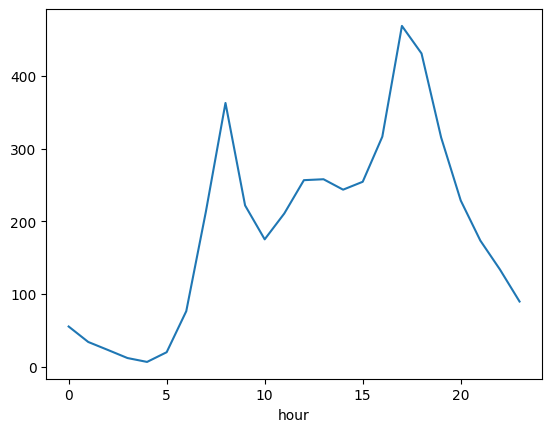

In [7]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

<Axes: xlabel='hour'>

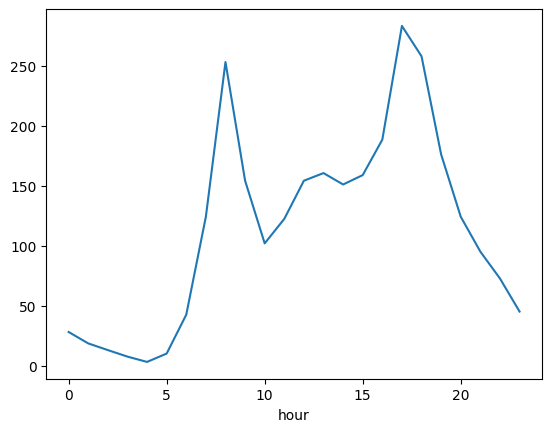

In [8]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes[bikes['season'] == 1].groupby('hour').total.mean().plot()

<Axes: xlabel='hour'>

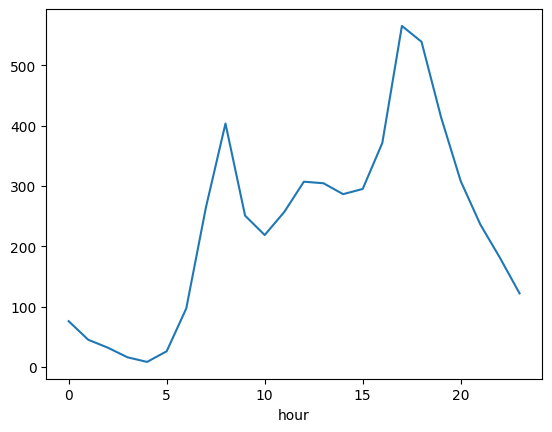

In [9]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes[bikes['season'] == 3].groupby('hour').total.mean().plot()

### Análisis P2
Al analizar las gráficas del número promedio de bicicletas rentadas por hora para invierno (season = 1) y verano (season = 3), se observan patrones similares en cuanto a la forma de la demanda, pero con diferencias importantes en magnitud.

En ambos casos se mantiene el comportamiento bimodal, con picos en horas de la mañana (7–9 AM) y en la tarde (4–6 PM), lo que confirma que el uso del sistema está fuertemente relacionado con los horarios de desplazamiento laboral, independientemente de la estación.

Sin embargo, en la temporada de verano (season = 3), la demanda es significativamente mayor en casi todas las horas del día en comparación con el invierno. Esto sugiere que condiciones climáticas más favorables no solo incrementan el uso general del sistema, sino que también intensifican los picos de demanda en horas clave.

Adicionalmente, durante el invierno se observa una caída más pronunciada en las horas de baja actividad (madrugada), mientras que en verano la demanda, aunque baja, tiende a ser ligeramente superior incluso en estos periodos.

En conjunto, estos resultados refuerzan que:

+ La variable hour determina el patrón de uso (forma de la curva).
+ La variable season afecta la intensidad de la demanda (altura de la curva).

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [11]:
# Celda 3
X = bikes[['season','hour']]
y = bikes['total']
# Para no tener en cuenta las magnitudes de 1-4 de las temporadas, ahora como baseline queda season_1.
X = pd.get_dummies(X, columns = ['season'], drop_first = True)

linreg = LinearRegression()
linreg.fit(X,y)

# Dict con los coeficientes
coeficientes_linreg = pd.DataFrame({'variable': X.columns, 'coeff': linreg.coef_})

coeficientes_linreg

,variable,coeff
0,hour,10.545206
1,season_2,100.317232
2,season_3,119.467550
3,season_4,84.083118


### Análisis P3
El coeficiente asociado a la variable hour indica el cambio promedio en el número de bicicletas rentadas por cada incremento de una hora. Sin embargo, dado que la relación observada previamente es no lineal (con picos en horas específicas), este coeficiente representa un promedio que no captura adecuadamente las variaciones reales en la demanda.

Por otro lado, los coeficientes de las variables season_2, season_3 y season_4 representan el cambio promedio en la demanda con respecto a la temporada base (season 1). En general, estos coeficientes son positivos, lo que indica que las demás temporadas presentan mayor demanda en comparación con el invierno, siendo la temporada 3 la de mayor impacto.

Todas estas relaciones se resumen en la siguiente tabla:

| Variable | Coeficiente | Interpretación                                                                                                                                                                                                                                                                   |
| -------- | ----------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| hour     | 10.55       | Por cada incremento de una hora, el modelo estima un aumento promedio de aproximadamente 10.5 bicicletas rentadas, manteniendo constante la temporada. Este resultado representa un efecto promedio, ya que el comportamiento real es no lineal, con picos en horas específicas. |
| season_2 | 100.32      | En la temporada 2 se rentan en promedio 100 bicicletas más que en la temporada 1, manteniendo constante la hora.                                                                                                                                                                 |
| season_3 | 119.47      | En la temporada 3 se rentan aproximadamente 119 bicicletas más que en la temporada 1, lo que confirma que es la temporada con mayor demanda.                                                                                                                                     |
| season_4 | 84.08       | En la temporada 4 se rentan cerca de 84 bicicletas más que en la temporada 1.                                                                                                                                                                                                    |

Por otro lado, existe una limitación importante de la regresión lineal en este caso. La variable hour presenta un comportamiento claramente no lineal, con la existencia de picos y valles a lo largo del día; sin embargo, el modelo la representa como un crecimiento constante. Esto genera una pérdida de información relevante sobre los patrones reales de uso.

En conclusión, aunque la regresión lineal permite identificar tendencias generales y diferencias entre temporadas, no logra capturar la estructura no lineal ni los cambios de comportamiento en distintos rangos horarios, lo que limita su capacidad predictiva en este problema.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [21]:
# Celda 4
# Iteración basada en el MSE para regresion GINI index para clasificación
def mse(y):
    if len(y) == 0:
        return 0
    return np.var(y)

def mse_reduction(X_col, y, split):
    
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n = len(y)
    n_l = len(y_l)
    n_r = len(y_r)
    
    if n_l == 0 or n_r == 0:
        return 0
    
    mse_parent = mse(y)
    mse_l = mse(y_l)
    mse_r = mse(y_r)
    
    weighted_mse = (n_l/n)*mse_l + (n_r/n)*mse_r
    
    return mse_parent - weighted_mse
    
# Definición de la función best_split para calcular cuál es la mejor variable y punto de cortepara hacer la bifurcación del árbol
def best_split(X, y, num_pct=10):
    
    features = range(X.shape[1])
    best_split = [0, 0, -np.inf]  # j, split, gain
    
    for j in features:
        
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        for split in splits:
            gain = mse_reduction(X.iloc[:, j], y, split)
            
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split

# Definición de la función tree_grow para hacer un crecimiento recursivo del árbol
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    
    n_samples = X.shape[0]
    
    # Predicción del nodo (regresión)
    y_pred = y.mean()
    
    tree = dict(
        y_pred=y_pred,
        level=level,
        split=None,
        n_samples=n_samples,
        gain=0
    )
    
    # Caso base: una sola observación
    if n_samples <= 1:
        return tree
    
    # Buscar mejor split
    j, split, gain = best_split(X, y, num_pct)
    
    tree['gain'] = gain
    
    # Criterios de parada
    if gain < min_gain:
        return tree
    
    if max_depth is not None and level >= max_depth:
        return tree
    
    if j is None:
        return tree
    
    # Aplicar split
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    
    # Validar split
    if len(y_l) == 0 or len(y_r) == 0:
        return tree
    
    tree['split'] = [j, split]
    
    # Siguiente iteración para cada partición
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain, max_depth, num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain, max_depth, num_pct)
    
    return tree

# Data season y hour
X = bikes[['hour', 'season']]
y = bikes['total']
# Para 6 nodos tenemos max_depth = 3
tree = tree_grow(X, y, max_depth=3, min_gain=0.001)
# print(tree)

def tree_predict(X, tree):
    
    predicted = np.zeros(X.shape[0])

    # Nodo hoja
    if tree['split'] is None:
        predicted = predicted + tree['y_pred']
        
    else:
        j, split = tree['split']
        
        filter_l = (X.iloc[:, j] < split)
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]

        # Casos borde (aunque casi no deberían pasar)
        if X_l.shape[0] == 0:
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])
            
        elif X_r.shape[0] == 0:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
            
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])

    return predicted

print(tree_predict(X, tree))

# Predicciones
y_pred_train_manual = tree_predict(X_train, tree)
y_pred_val_manual = tree_predict(X_val, tree)

# RMSE
rmse_train_manual = np.sqrt(np.mean((y_train - y_pred_train_manual)**2))
rmse_val_manual = np.sqrt(np.mean((y_val - y_pred_val_manual)**2))

print("Manual RMSE Train:", rmse_train_manual)
print("Manual RMSE Validation:", rmse_val_manual)

tree

[ 25.17771982  25.17771982  25.17771982 ... 152.47563353 152.47563353
 152.47563353]
Manual RMSE Train: 132.14330389056087
Manual RMSE Validation: 130.83345568001397


{'y_pred': np.float64(191.57413191254824),
 'level': 0,
 'split': [0, np.float64(8.0)],
 'n_samples': 10886,
 'gain': np.float64(9134.40591176651),
 'sl': {'y_pred': np.float64(55.437673900946024),
  'level': 1,
  'split': [0, np.float64(7.0)],
  'n_samples': 3594,
  'gain': np.float64(3603.8503299798276),
  'sl': {'y_pred': np.float64(32.58203249442498),
   'level': 2,
   'split': [0, np.float64(6.0)],
   'n_samples': 3139,
   'gain': np.float64(323.4004463794779),
   'sl': {'y_pred': np.float64(25.177719821162444),
    'level': 3,
    'split': None,
    'n_samples': 2684,
    'gain': np.float64(191.40441543023144)},
   'sr': {'y_pred': np.float64(76.25934065934067),
    'level': 3,
    'split': None,
    'n_samples': 455,
    'gain': np.float64(371.54779616750875)}},
  'sr': {'y_pred': np.float64(213.11648351648353),
   'level': 2,
   'split': [1, np.float64(2.0)],
   'n_samples': 455,
   'gain': np.float64(2598.553552876696),
   'sl': {'y_pred': np.float64(124.43362831858407),
    '

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

Best max_depth: 8
Best CV RMSE: 113.72487937147491
RMSE Train: 112.81030742668983
RMSE Validation: 115.10288184795918


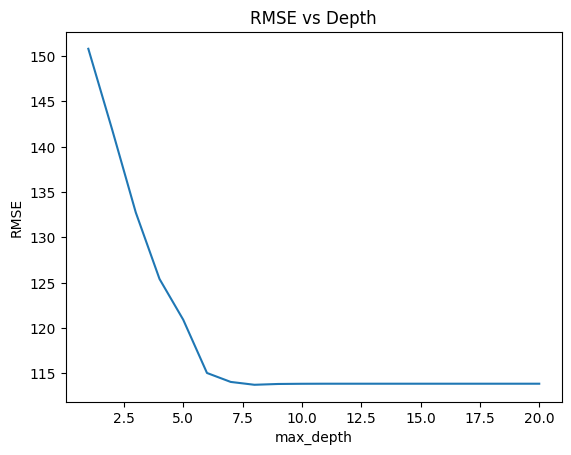

In [20]:
# Celda 5
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error

X = bikes[['hour', 'season']]
y = bikes['total']

# Split train / validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=99)

max_depth_range = range(1, 21)
rmse_scores = []

for depth in max_depth_range:
    
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    
    # Validación cruzada (solo en train)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=10,
        scoring='neg_mean_squared_error'
    )
    
    rmse = np.sqrt(-scores.mean())
    rmse_scores.append(rmse)

# Mejor depth (menor RMSE)
best_rmse, best_depth = sorted(zip(rmse_scores, max_depth_range))[0]

print("Best max_depth:", best_depth)
print("Best CV RMSE:", best_rmse)

final_model = DecisionTreeRegressor(
    max_depth=best_depth,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

final_model.fit(X_train, y_train)

y_pred_train = final_model.predict(X_train)
y_pred_val = final_model.predict(X_val)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))

print("RMSE Train:", rmse_train)
print("RMSE Validation:", rmse_val)

import matplotlib.pyplot as plt
plt.plot(max_depth_range, rmse_scores)
plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.title("RMSE vs Depth")
plt.show()

### Análisis P5
El modelo de árbol de regresión fue calibrado utilizando validación cruzada con 10 folds, evaluando el desempeño mediante el RMSE. El mejor valor de profundidad encontrado fue max_depth = 8, con un RMSE promedio de validación cruzada de aproximadamente 113.72.

Al entrenar el modelo final con este valor, se obtuvieron los siguientes resultados:

+ RMSE Train: 112.81
+ RMSE Validation: 115.10

La cercanía entre el error de entrenamiento y el de validación indica que el modelo presenta un buen balance entre sesgo y varianza, sin evidencia significativa de sobreajuste. Esto sugiere que la profundidad seleccionada permite capturar patrones relevantes en los datos sin memorizar el ruido.

El árbol implementado manualmente también utiliza el MSE como criterio de división y una profundidad limitada (árbol pequeño de aproximadamente 6 nodos). Los resultados obtenidos fueron:

+ RMSE Train: 132.14
+ RMSE Validation: 130.83

Al comparar ambos modelos, se observan dos conclusiones importantes:

1. Generalización: En ambos casos, el error de entrenamiento y validación es similar, lo que indica que ninguno de los modelos presenta sobreajuste. Ambos logran generalizar de manera estable sobre datos no vistos.

2. Desempeño: El modelo de sklearn presenta un RMSE significativamente menor (≈15–20 unidades menos), lo que evidencia una mejor capacidad predictiva.

Esta diferencia se explica principalmente por:

Mayor profundidad del árbol (max_depth = 8), que permite capturar relaciones más complejas, la optimización más precisa de los puntos de corte, mientras que el modelo manual usa aproximaciones y posee un mejor manejo de criterios de parada y regularización.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [25]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [26]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [27]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [33]:
# Celda 6
# Arbol de decision 
# Calibración de max_depth a través de f1_scores
depth_range = range(1, 21)
f1_scores = []

for depth in depth_range:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=1)
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1').mean()
    f1_scores.append(score)

best_depth = depth_range[np.argmax(f1_scores)]
print("Best max_depth:", best_depth)

# Modelo final max_depth optimo arbol
tree = DecisionTreeClassifier(max_depth=best_depth, random_state=1)
tree.fit(X_train, y_train)

# Predicciones arbol
y_pred_tree = tree.predict(X_test)

# Metricas arbol
acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
print("Árbol de Decisión")
print("Accuracy:", acc_tree)
print("F1-score:", f1_tree)

# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_log = logreg.predict(X_test)

# Métricas Regresion LOG
acc_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
print("\nRegresión Logística")
print("Accuracy:", acc_log)
print("F1-score:", f1_log)

Best max_depth: 4
Árbol de Decisión
Accuracy: 0.6513333333333333
F1-score: 0.6345213137665968

Regresión Logística
Accuracy: 0.6186666666666667
F1-score: 0.6060606060606061


### Análisis P6
Los resultados de los modelos se observan en la siguiente tabla:

| Modelo               | Accuracy | F1-score |
|---------------------|----------|----------|
| Árbol de Decisión   | 0.6513   | 0.6345   |
| Regresión Logística | 0.6187   | 0.6061   |

Se construyeron dos modelos de clasificación para predecir la popularidad de noticias: un árbol de decisión y una regresión logística. Para el árbol, se calibró el hiperparámetro max_depth, obteniendo como mejor valor una profundidad de 4.

Al comparar los resultados, el árbol de decisión presenta un mejor desempeño tanto en Accuracy (0.6513) como en F1-score (0.6345) frente a la regresión logística. Esto sugiere que el árbol logra capturar mejor las relaciones en los datos, posiblemente debido a su capacidad de modelar relaciones no lineales entre las variables predictoras y la variable objetivo.

Por otro lado, aunque la regresión logística tiene un desempeño ligeramente inferior, sigue siendo un modelo competitivo y más simple, lo que puede ser útil en escenarios donde se prioriza interpretabilidad y estabilidad.

En general, los valores de F1-score son consistentes con los de accuracy, lo que indica que el modelo mantiene un balance razonable entre precisión y recall.

El desempeño relativamente bajo de los modelos puede explicarse tanto por la limitada cantidad de variables predictoras como por la complejidad inherente del problema, el cual depende de múltiples factores externos difíciles de capturar. Esto sugiere que modelos más complejos, como métodos de ensamblaje (Random Forest o Gradient Boosting), podrían mejorar significativamente el desempeño.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [35]:
# Celda 7
n_models = 100
preds_all = []

# 100 Árboles (mismo max_depth) diferente semilla
preds_depth = []

for i in range(n_models):
    X_bs, y_bs = resample(X_train, y_train, replace=True, random_state=i)
    
    model = DecisionTreeClassifier(max_depth=4, random_state=1)
    model.fit(X_bs, y_bs)
    
    pred = model.predict(X_test)
    preds_depth.append(pred)
    preds_all.append(pred)

preds_depth = np.array(preds_depth)

# 100 Árboles (min_samples_leaf) diferente semilla
preds_leaf = []

for i in range(n_models):
    X_bs, y_bs = resample(X_train, y_train, replace=True, random_state=100+i)
    
    model = DecisionTreeClassifier(min_samples_leaf=10, random_state=1)
    model.fit(X_bs, y_bs)
    
    pred = model.predict(X_test)
    preds_leaf.append(pred)
    preds_all.append(pred)

preds_leaf = np.array(preds_leaf)

# 100 Regresiones Logísticas diferente semilla
preds_log = []

for i in range(n_models):
    X_bs, y_bs = resample(X_train, y_train, replace=True, random_state=200+i)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_bs, y_bs)
    
    pred = model.predict(X_test)
    preds_log.append(pred)
    preds_all.append(pred)

preds_log = np.array(preds_log)
preds_all = np.array(preds_all)

# Evaluación individual (promedio)
def evaluate_ensemble(preds, y_true):
    avg_pred = (preds.mean(axis=0) >= 0.5).astype(int)
    acc = accuracy_score(y_true, avg_pred)
    f1 = f1_score(y_true, avg_pred)
    return acc, f1

# Aplicación a cada modelo
acc_depth, f1_depth = evaluate_ensemble(preds_depth, y_test)
acc_leaf, f1_leaf = evaluate_ensemble(preds_leaf, y_test)
acc_log, f1_log = evaluate_ensemble(preds_log, y_test)

# Ensamble total (300 modelos)
final_pred = (preds_all.mean(axis=0) >= 0.5).astype(int)

acc_total = accuracy_score(y_test, final_pred)
f1_total = f1_score(y_test, final_pred)

# Resultados
print("Árboles (max_depth):", acc_depth, f1_depth)
print("Árboles (min_samples_leaf):", acc_leaf, f1_leaf)
print("Regresión Logística:", acc_log, f1_log)
print("Ensamble total:", acc_total, f1_total)

Árboles (max_depth): 0.6466666666666666 0.6384720327421555
Árboles (min_samples_leaf): 0.6513333333333333 0.6444595513256288
Regresión Logística: 0.6166666666666667 0.6037215713301172
Ensamble total: 0.642 0.6314344543582704


### Análisis P7
Los resultados de los modelos aplicados se muestran en la siguiente tabla:

| Modelo                          | Accuracy | F1-score |
|---------------------------------|----------|----------|
| Árboles (max_depth)             | 0.6467   | 0.6385   |
| Árboles (min_samples_leaf)      | 0.6513   | 0.6445   |
| Regresión Logística             | 0.6167   | 0.6037   |
| Ensamble total (300 modelos)    | 0.6420   | 0.6314   |

El ensamble construido mediante votación mayoritaria no supera el desempeño de los mejores modelos individuales (árboles de decisión). Esto se debe a que, aunque el ensamble combina múltiples modelos, todos los clasificadores tienen el mismo peso en la votación, incluyendo aquellos con menor desempeño como la regresión logística.

Como resultado, los modelos más débiles introducen ruido en la decisión final, reduciendo ligeramente el desempeño global del ensamble. Este comportamiento evidencia que la efectividad de los métodos de ensamblaje no depende únicamente del número de modelos, sino también de la calidad individual de estos y de la forma en que se combinan.

### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [36]:
# Celda 8 
# Usando OOB como criterio del ponderador
n_models = 100

preds_all = []
weights_all = []

# Función para obtener OOB
def get_oob(X_train, y_train, indices):
    mask = np.ones(len(X_train), dtype=bool)
    # Indices de los resultados fuera de la bolsa
    mask[indices] = False
    return X_train[mask], y_train[mask]

# Árboles (max_depth)
for i in range(n_models):
    indices = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_bs = X_train.iloc[indices]
    y_bs = y_train.iloc[indices]
    
    X_oob, y_oob = get_oob(X_train, y_train, indices)
    
    model = DecisionTreeClassifier(max_depth=4, random_state=1)
    model.fit(X_bs, y_bs)
    
    pred_test = model.predict(X_test)
    
    # Peso con OOB
    if len(X_oob) > 0:
        pred_oob = model.predict(X_oob)
        weight = f1_score(y_oob, pred_oob)
    else:
        # Peso mínimo
        weight = 0.5
    
    preds_all.append(pred_test)
    weights_all.append(weight)

# Árboles (min_samples_leaf)
for i in range(n_models):
    indices = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_bs = X_train.iloc[indices]
    y_bs = y_train.iloc[indices]
    
    X_oob, y_oob = get_oob(X_train, y_train, indices)
    
    model = DecisionTreeClassifier(min_samples_leaf=10, random_state=1)
    model.fit(X_bs, y_bs)
    
    pred_test = model.predict(X_test)
    
    if len(X_oob) > 0:
        pred_oob = model.predict(X_oob)
        weight = f1_score(y_oob, pred_oob)
    else:
        weight = 0.5
    
    preds_all.append(pred_test)
    weights_all.append(weight)

# Regresión Logística
for i in range(n_models):
    indices = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_bs = X_train.iloc[indices]
    y_bs = y_train.iloc[indices]
    
    X_oob, y_oob = get_oob(X_train, y_train, indices)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_bs, y_bs)
    
    pred_test = model.predict(X_test)
    
    if len(X_oob) > 0:
        pred_oob = model.predict(X_oob)
        weight = f1_score(y_oob, pred_oob)
    else:
        weight = 0.5
    
    preds_all.append(pred_test)
    weights_all.append(weight)

# Votación ponderada
preds_all = np.array(preds_all)
weights_all = np.array(weights_all)

weighted_votes = np.average(preds_all, axis=0, weights=weights_all)
final_pred = (weighted_votes >= 0.5).astype(int)

# Métricas
acc_weighted = accuracy_score(y_test, final_pred)
f1_weighted = f1_score(y_test, final_pred)

print("Weighted Voting (OOB)")
print("Accuracy:", acc_weighted)
print("F1-score:", f1_weighted)

Weighted Voting (OOB)
Accuracy: 0.638
F1-score: 0.6288448393711552


           modelo        peso
count  300.000000  300.000000
mean   149.500000    0.590039
std     86.746758    0.031493
min      0.000000    0.495941
25%     74.750000    0.562788
50%    149.500000    0.596723
75%    224.250000    0.612899
max    299.000000    0.667430


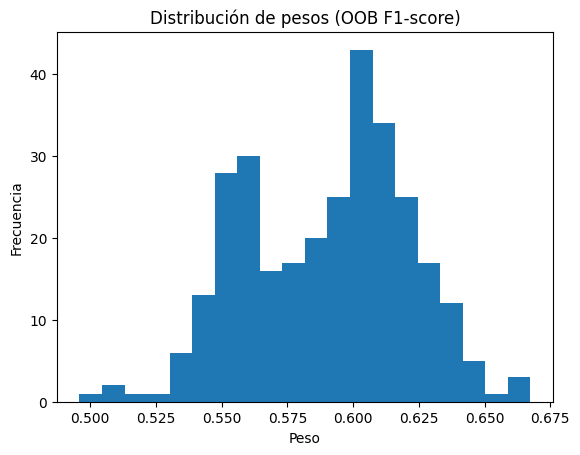

In [37]:
# Pesos utilizados
weights_df = pd.DataFrame({"modelo": range(len(weights_all)),"peso": weights_all})
print(weights_df.describe())

plt.hist(weights_all, bins=20)
plt.title("Distribución de pesos (OOB F1-score)")
plt.xlabel("Peso")
plt.ylabel("Frecuencia")
plt.show()

### Análisis P8
El ensamble mediante votación ponderada utilizando errores Out-Of-Bag obtuvo un Accuracy de 0.638 y un F1-score de 0.6288, lo que refleja un desempeño moderado en la tarea de clasificación de la popularidad de noticias.

La cercanía entre ambas métricas sugiere que el modelo mantiene un balance adecuado entre precisión y recall, sin sesgos marcados hacia alguna de las clases.

No obstante, al comparar estos resultados con los obtenidos mediante votación mayoritaria y modelos individuales (en particular, los árboles de decisión), se observa que la votación ponderada no logra mejorar el desempeño, presentando incluso una ligera disminución.

Este comportamiento se explica por la baja variabilidad en los pesos asignados a los modelos, evidenciada en su distribución aproximadamente normal y concentrada en un rango estrecho entre 0.5 y 0.675, con una media cercana a 0.59. Esto indica que los modelos individuales tienen desempeños muy similares, sin diferencias significativas que permitan asignar mayor relevancia a algunos clasificadores sobre otros.

En consecuencia, la votación ponderada se comporta de manera muy similar a la votación mayoritaria, ya que ningún modelo domina la decisión final. Este resultado evidencia que la efectividad de los ensambles ponderados depende de la existencia de heterogeneidad en el desempeño de los modelos base, condición que no se cumple en este caso.

### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

### Análisis P9
El resumen de todo los resultados se condensa en la siguiente tabla:

| Modelo                          | Accuracy | F1-score |
|---------------------------------|----------|----------|
| Árboles (max_depth)             | 0.6467   | 0.6385   |
| Árboles (min_samples_leaf)      | 0.6513   | 0.6445   |
| Regresión Logística             | 0.6167   | 0.6037   |
| Votación mayoritaria            | 0.6420   | 0.6314   |
| Votación ponderada (OOB)        | 0.6380   | 0.6288   |

Los resultados muestran que los modelos individuales basados en árboles de decisión presentan el mejor desempeño, superando tanto a la regresión logística como a los ensambles construidos mediante votación.

El ensamble por votación mayoritaria logra un desempeño competitivo, aunque ligeramente inferior al de los mejores modelos individuales. Esto sugiere que, si bien el bagging ayuda a reducir la varianza, la combinación de modelos no necesariamente mejora la capacidad predictiva cuando los modelos base ya son similares.

Por su parte, la votación ponderada utilizando errores Out-Of-Bag no logra mejorar los resultados de la votación mayoritaria. Esto se explica por la baja variabilidad en los pesos asignados, lo que hace que el esquema ponderado se comporte de forma muy similar a una votación simple.

En conjunto, estos resultados evidencian que el uso de ensambles no garantiza mejoras automáticas, especialmente cuando los modelos base tienen desempeños homogéneos y el problema presenta una señal limitada.

**Ventajas y desventajas de los modelos implementados**

**Votación mayoritaria**

 Ventajas

+ Fácil de implementar e interpretar
+ Reduce la varianza mediante bagging
+ Robusta frente a ruido en modelos individuales
+ No requiere cálculo adicional de pesos

Desventajas

+ Todos los modelos tienen el mismo peso (incluso los peores)
+ Puede verse afectada por modelos débiles
+ No aprovecha diferencias en desempeño entre modelos

**Votación ponderada (OOB)**

Ventajas

+ Asigna mayor importancia a modelos con mejor desempeño
+ Utiliza datos OOB, evitando sobreajuste en la estimación del peso
+ Conceptualmente más robusta que la votación simple
+ Permite incorporar información de calidad de los modelos

Desventajas

+ Mayor complejidad computacional
+ Depende de que exista variabilidad en el desempeño de los modelos
+ Si los modelos son similares, no aporta mejoras significativas
+ Sensible a estimaciones inestables de los pesos (si OOB es pequeño)
  
En este caso, la votación ponderada no supera a la votación mayoritaria debido a la homogeneidad en el desempeño de los modelos base. Esto demuestra que la efectividad de los métodos de ensamblaje depende no solo de la cantidad de modelos, sino de la diversidad y calidad de estos, así como de la capacidad del método de combinación para explotar dichas diferencias.